# DIEU YEN DIEP: VISUALISATION AND DOCUMENTATION

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

possible_folders = [Path.cwd(), Path.cwd() / "Data Science", Path.home() / "Desktop" / "Data Science"]
project_folder = next(
    (folder.resolve() for folder in possible_folders if (folder / "Fire2Air_model_ready_checkpoint.csv").exists()),
    None,
)
if project_folder is None:
    raise FileNotFoundError("Fire2Air_model_ready_checkpoint.csv not found. Run Thi's notebook first.")

output_root = project_folder / "outputs_prt661"
table_dir = output_root / "tables"
figure_dir = output_root / "figures"
for folder in [table_dir, figure_dir]:
    folder.mkdir(parents=True, exist_ok=True)

model_table = pd.read_csv(
    project_folder / "Fire2Air_model_ready_checkpoint.csv",
    parse_dates=["date", "target_date"],
)
daily_air = pd.read_csv(
    project_folder / "Fire2Air_ntepa_daily_checkpoint.csv",
    parse_dates=["date"],
)
fire_daily = pd.read_csv(
    project_folder / "Fire2Air_firms_daily_checkpoint.csv",
    parse_dates=["date_darwin"],
)
with open(project_folder / "Fire2Air_feature_manifest.json", "r", encoding="utf-8") as f:
    manifest = json.load(f)
model_features = manifest["features"]
PM25_THRESHOLD = float(manifest["threshold_pm25_ug_m3"])
MAX_FIRE_DISTANCE_KM = float(manifest["max_fire_distance_km"])

print("Project folder:", project_folder)
print("Model-ready rows:", len(model_table))
print("Predictors:", len(model_features))

Project folder: C:\Users\khuep\Desktop\PRT661---DATA-SCIENCE-PRACTICE---Dan5---Theme2\Source code
Model-ready rows: 7530
Predictors: 22


## A. Updated implementation architecture

This figure documents the implemented Assessment 2 flow rather than the earlier proposal-only design.

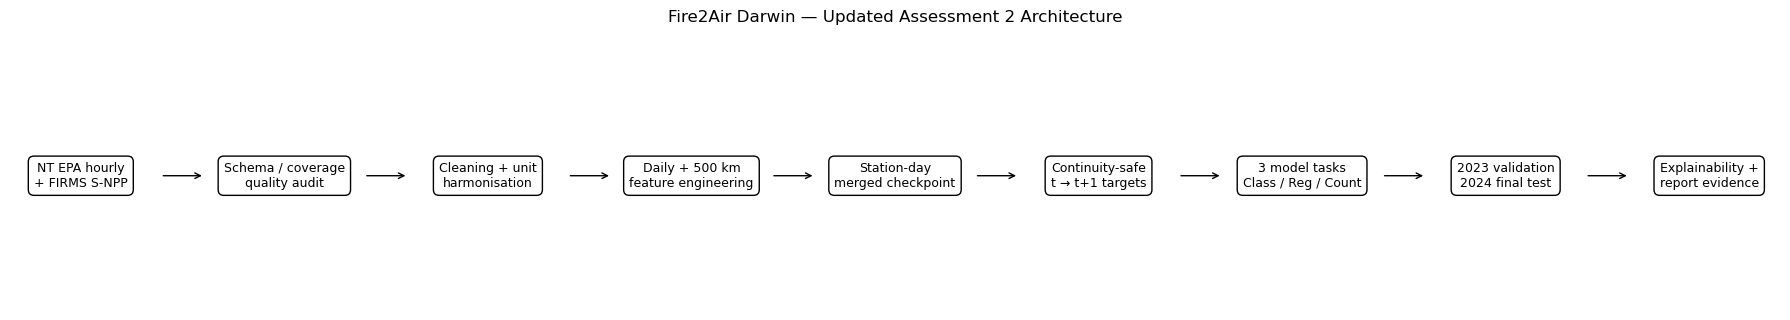

In [2]:
stages = [
    "NT EPA hourly\n+ FIRMS S-NPP",
    "Schema / coverage\nquality audit",
    "Cleaning + unit\nharmonisation",
    "Daily + 500 km\nfeature engineering",
    "Station-day\nmerged checkpoint",
    "Continuity-safe\nt → t+1 targets",
    "3 model tasks\nClass / Reg / Count",
    "2023 validation\n2024 final test",
    "Explainability +\nreport evidence",
]

fig, ax = plt.subplots(figsize=(18, 3.3))
ax.axis("off")
xs = np.linspace(0.04, 0.96, len(stages))
for i, (x, label) in enumerate(zip(xs, stages)):
    ax.text(
        x, 0.5, label, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="black"),
        transform=ax.transAxes, fontsize=9,
    )
    if i < len(stages) - 1:
        ax.annotate(
            "", xy=(xs[i + 1] - 0.045, 0.5), xytext=(x + 0.045, 0.5),
            xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->"),
        )
ax.set_title("Fire2Air Darwin — Updated Assessment 2 Architecture", pad=14)
fig.tight_layout()
fig.savefig(figure_dir / "01_updated_architecture.png", dpi=180, bbox_inches="tight")
plt.show()

## B. EDA: PM₂.₅ trends, distributions, seasonality and exceedances

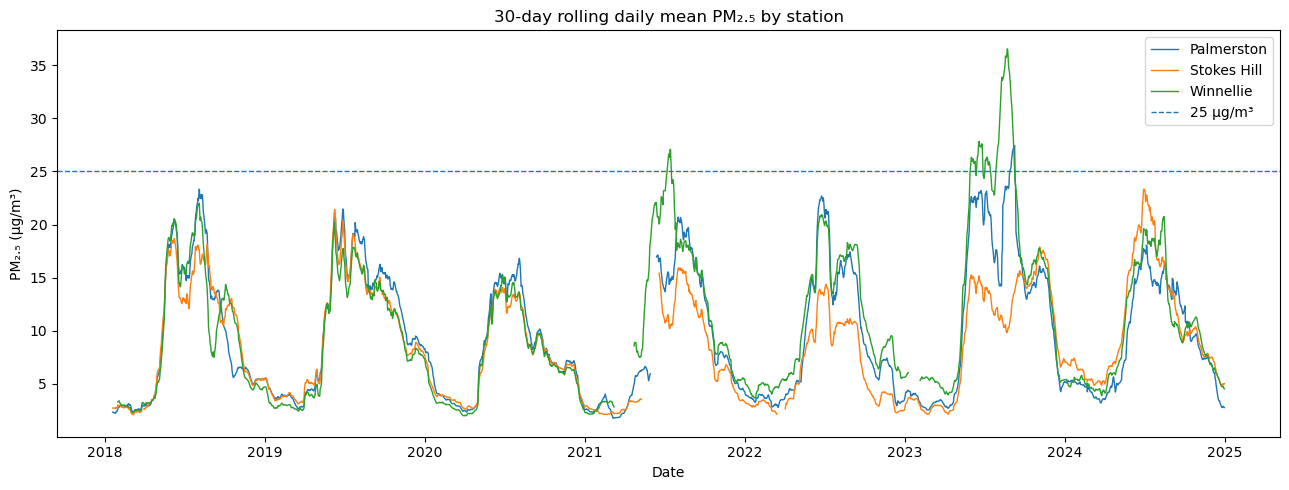

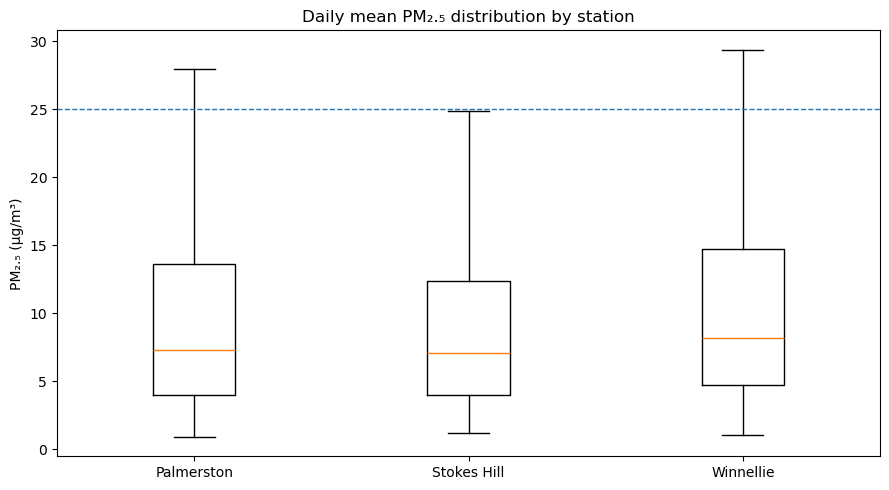

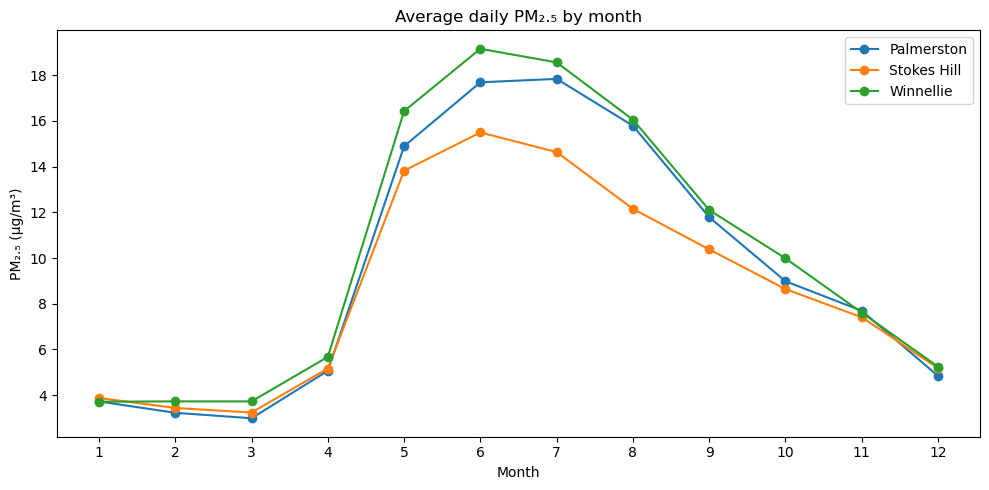

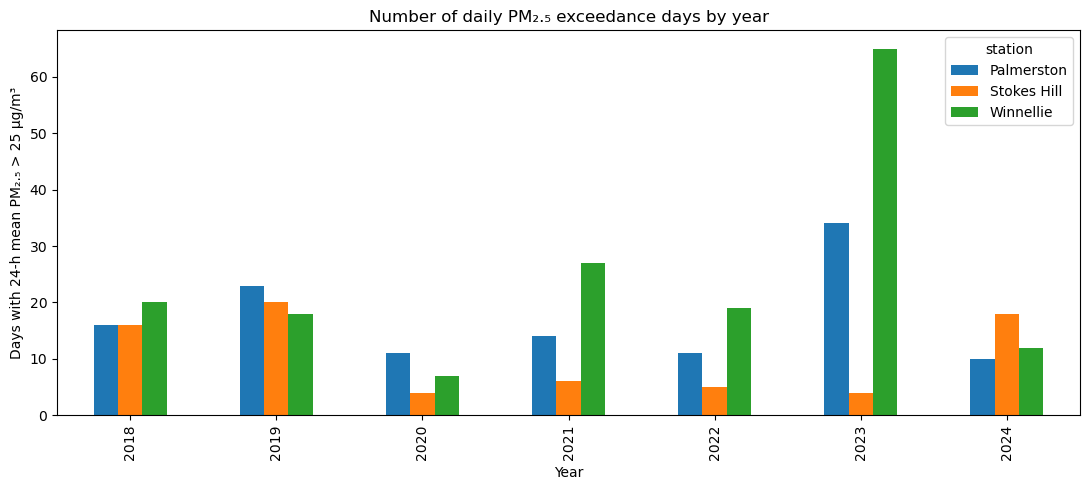

In [3]:
# 30-day rolling PM2.5 trend by station.
fig, ax = plt.subplots(figsize=(13, 5))
for station, g in daily_air.sort_values("date").groupby("station"):
    smoothed = g.set_index("date")["pm25_mean"].rolling(30, min_periods=10).mean()
    ax.plot(smoothed.index, smoothed.values, label=station, linewidth=1)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1, label="25 µg/m³")
ax.set_title("30-day rolling daily mean PM₂.₅ by station")
ax.set_xlabel("Date"); ax.set_ylabel("PM₂.₅ (µg/m³)"); ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "02_pm25_trend_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

# Distribution by station.
stations = sorted(daily_air["station"].dropna().unique())
data = [daily_air.loc[daily_air["station"].eq(s), "pm25_mean"].dropna() for s in stations]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=stations, showfliers=False)
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Daily mean PM₂.₅ distribution by station")
ax.set_ylabel("PM₂.₅ (µg/m³)")
fig.tight_layout()
fig.savefig(figure_dir / "03_pm25_distribution_by_station.png", dpi=180, bbox_inches="tight")
plt.show()

# Monthly PM2.5 pattern.
monthly_pm = (
    daily_air.assign(month=daily_air["date"].dt.month)
    .groupby(["station", "month"])["pm25_mean"].mean().reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
for station, g in monthly_pm.groupby("station"):
    ax.plot(g["month"], g["pm25_mean"], marker="o", label=station)
ax.set_xticks(range(1, 13))
ax.set_title("Average daily PM₂.₅ by month")
ax.set_xlabel("Month"); ax.set_ylabel("PM₂.₅ (µg/m³)"); ax.legend()
fig.tight_layout()
fig.savefig(figure_dir / "04_monthly_pm25_pattern.png", dpi=180, bbox_inches="tight")
plt.show()

# Exceedance days by year and station.
exceedance_counts = (
    daily_air.dropna(subset=["pm25_mean"])
    .assign(year=lambda d: d["date"].dt.year, exceedance=lambda d: (d["pm25_mean"] > PM25_THRESHOLD).astype(int))
    .groupby(["year", "station"])["exceedance"].sum()
    .unstack("station").fillna(0)
)
ax = exceedance_counts.plot(kind="bar", figsize=(11, 5))
ax.set_title("Number of daily PM₂.₅ exceedance days by year")
ax.set_xlabel("Year"); ax.set_ylabel("Days with 24-h mean PM₂.₅ > 25 µg/m³")
fig = ax.get_figure(); fig.tight_layout()
fig.savefig(figure_dir / "05_exceedance_days_by_year.png", dpi=180, bbox_inches="tight")
plt.show()

## C. EDA: missingness and data coverage
These plots support the Assessment 2 discussion of data quality and limitations.

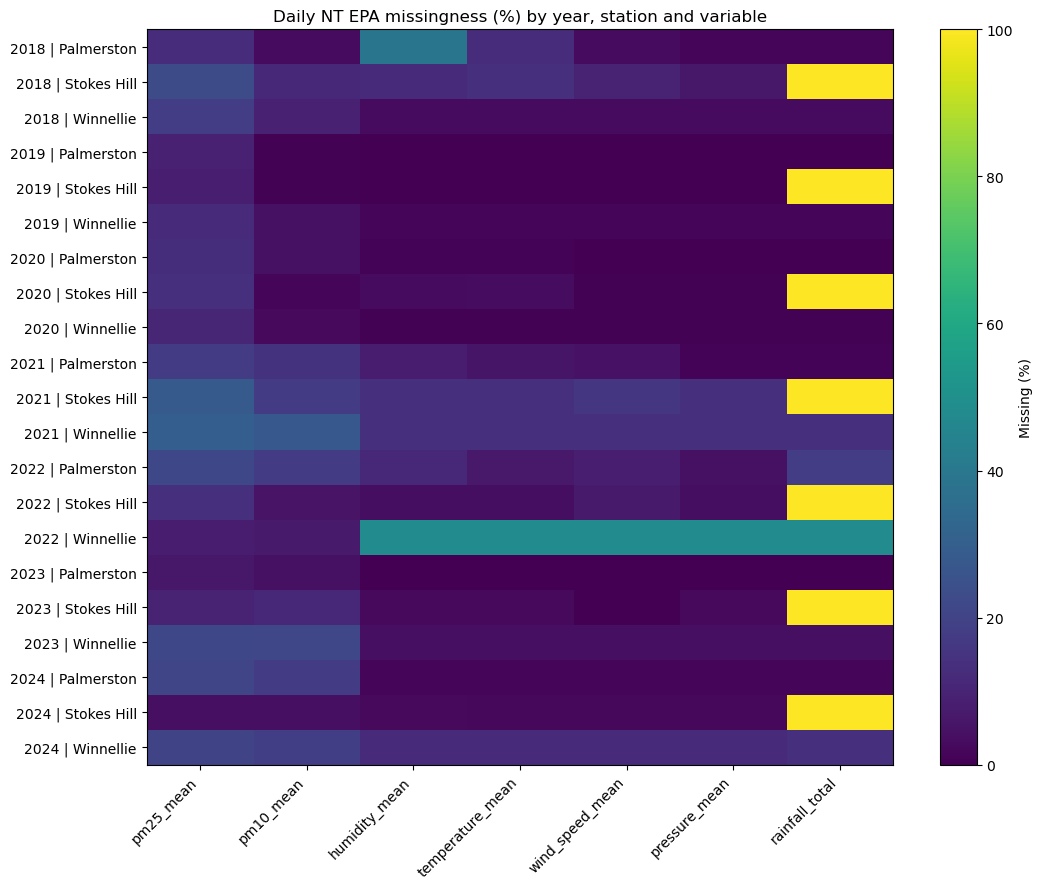


FIRMS local-day coverage:
 year  count  sum  mean  complete_pct
 2018   1095 1092  1.00         99.73
 2019   1095 1095  1.00        100.00
 2020   1098 1098  1.00        100.00
 2021   1095 1095  1.00        100.00
 2022   1095 1041  0.95         95.07
 2023   1095 1086  0.99         99.18
 2024   1098 1023  0.93         93.17


In [4]:
# Missingness (%) by year-station for important daily variables.
missing_cols = [
    "pm25_mean", "pm10_mean", "humidity_mean", "temperature_mean",
    "wind_speed_mean", "pressure_mean", "rainfall_total"
]
missing_cols = [c for c in missing_cols if c in daily_air.columns]
missing_matrix = (
    daily_air.assign(year=daily_air["date"].dt.year)
    .groupby(["year", "station"])[missing_cols]
    .agg(lambda s: s.isna().mean() * 100)
)
labels = [f"{y} | {s}" for y, s in missing_matrix.index]
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(missing_matrix.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(len(missing_cols))); ax.set_xticklabels(missing_cols, rotation=45, ha="right")
ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels)
ax.set_title("Daily NT EPA missingness (%) by year, station and variable")
cbar = fig.colorbar(im, ax=ax); cbar.set_label("Missing (%)")
fig.tight_layout()
fig.savefig(figure_dir / "06_missingness_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()
missing_matrix.reset_index().to_csv(table_dir / "eda_daily_missingness_by_year_station.csv", index=False)

# FIRMS local-day coverage summary.
coverage_summary = (
    fire_daily.assign(year=fire_daily["date_darwin"].dt.year)
    .groupby("year")["firms_local_day_complete"]
    .agg(["count", "sum", "mean"]).reset_index()
)
coverage_summary["complete_pct"] = 100 * coverage_summary["mean"]
print("\nFIRMS local-day coverage:")
print(coverage_summary.round(2).to_string(index=False))
coverage_summary.to_csv(table_dir / "eda_firms_local_day_coverage.csv", index=False)

## D. EDA: fire activity and PM₂.₅ relationships
The hybrid pipeline uses station-specific FIRMS features out to 500 km.

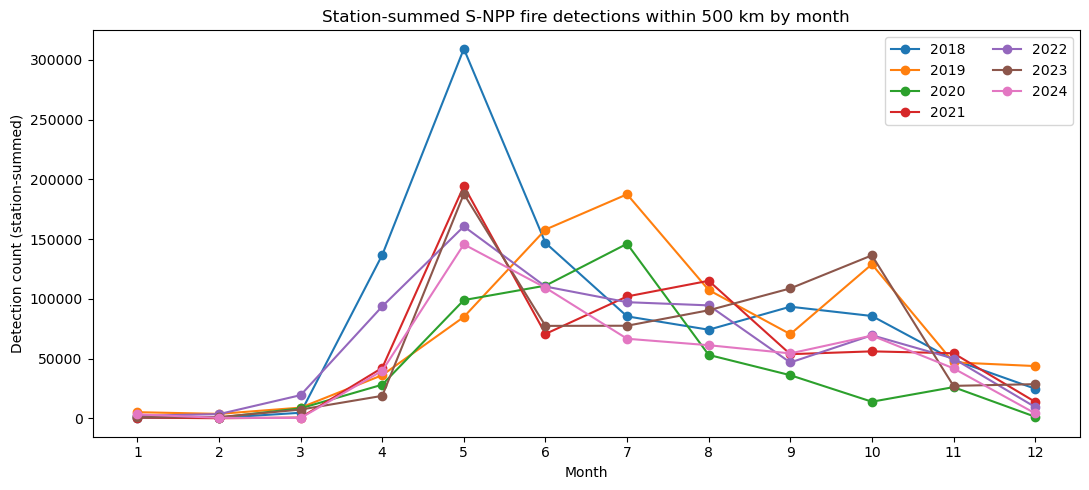

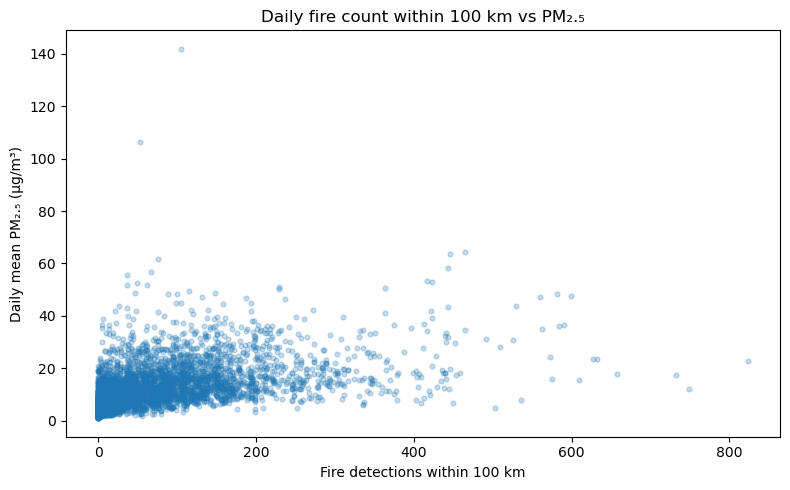

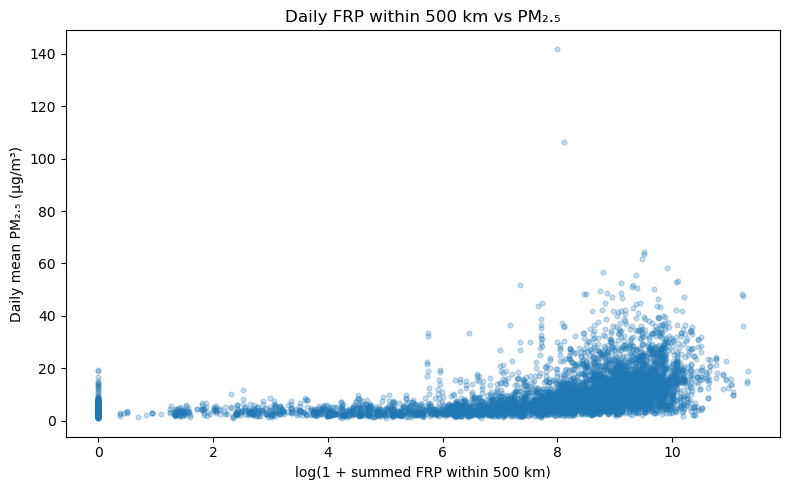

In [5]:
# Monthly fire detections within 500 km, summed over station-day features for a descriptive view.
fire_monthly = (
    fire_daily.assign(
        year=fire_daily["date_darwin"].dt.year,
        month=fire_daily["date_darwin"].dt.month,
    )
    .groupby(["year", "month"])["fire_count_0_500km"]
    .sum(min_count=1).reset_index(name="detections_station_sum")
)
fig, ax = plt.subplots(figsize=(11, 5))
for year, g in fire_monthly.groupby("year"):
    ax.plot(g["month"], g["detections_station_sum"], marker="o", label=str(year))
ax.set_xticks(range(1, 13))
ax.set_title("Station-summed S-NPP fire detections within 500 km by month")
ax.set_xlabel("Month"); ax.set_ylabel("Detection count (station-summed)"); ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(figure_dir / "07_fire_detections_by_month_year.png", dpi=180, bbox_inches="tight")
plt.show()

# Fire count vs same-day PM2.5.
eda = model_table.dropna(subset=["pm25_mean", "fire_count_50_100km"]).copy()
near_count = (
    eda["fire_count_0_25km"]
    + eda["fire_count_25_50km"]
    + eda["fire_count_50_100km"]
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(near_count, eda["pm25_mean"], alpha=0.25, s=12)
ax.set_title("Daily fire count within 100 km vs PM₂.₅")
ax.set_xlabel("Fire detections within 100 km"); ax.set_ylabel("Daily mean PM₂.₅ (µg/m³)")
fig.tight_layout()
fig.savefig(figure_dir / "08_fire_count_vs_pm25.png", dpi=180, bbox_inches="tight")
plt.show()

# FRP vs same-day PM2.5 using the complete 500 km feature.
eda_frp = model_table.dropna(subset=["pm25_mean", "frp_sum_0_500km"]).copy()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(np.log1p(eda_frp["frp_sum_0_500km"]), eda_frp["pm25_mean"], alpha=0.25, s=12)
ax.set_title("Daily FRP within 500 km vs PM₂.₅")
ax.set_xlabel("log(1 + summed FRP within 500 km)"); ax.set_ylabel("Daily mean PM₂.₅ (µg/m³)")
fig.tight_layout()
fig.savefig(figure_dir / "09_frp_vs_pm25.png", dpi=180, bbox_inches="tight")
plt.show()

## E. EDA: wind direction and correlation evidence

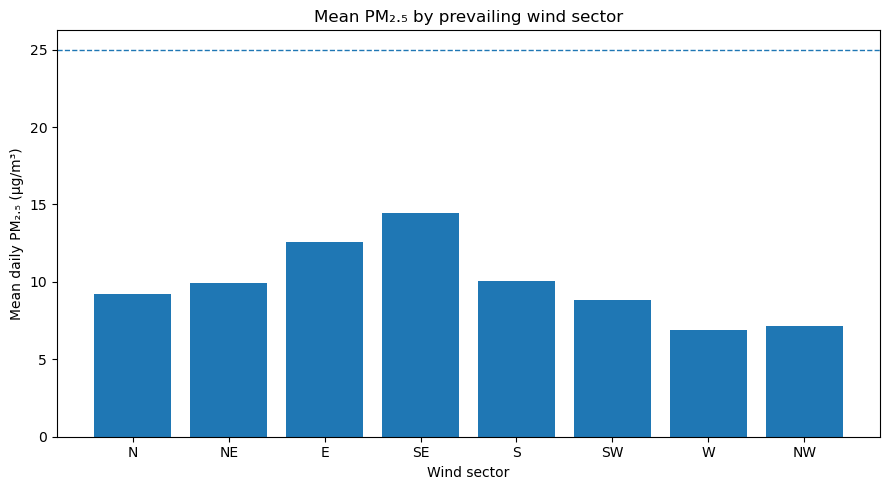


Top correlations with next-day PM2.5:
pm25_mean               0.771
pm25_3day_mean          0.751
pm25_lag1               0.698
pm10_mean               0.649
fire_count_100_200km    0.572
humidity_mean          -0.543
fire_count_50_100km     0.518
frp_sum_0_500km         0.508
fire_count_200_500km    0.505
fire_count_25_50km      0.504
month_cos              -0.498
pm25_max                0.490
temperature_mean       -0.462
pm10_max                0.424
nearest_fire_km        -0.413


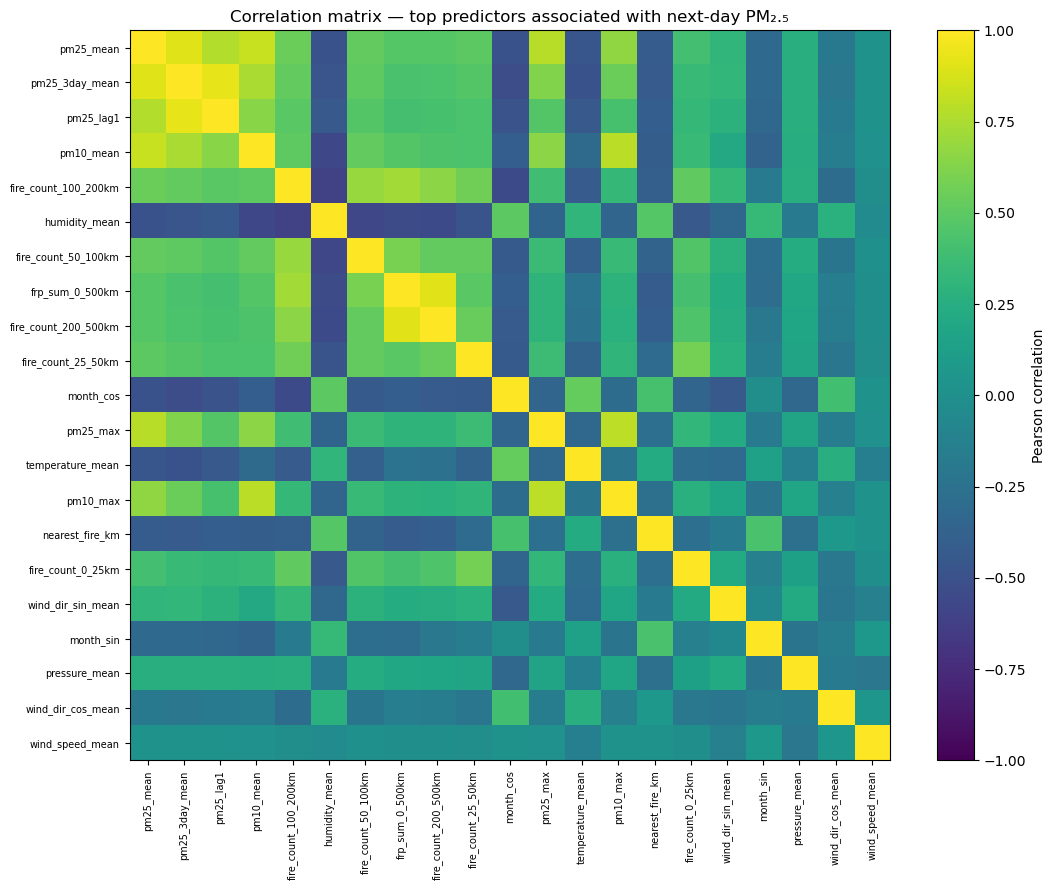

In [6]:
# Reconstruct daily prevailing wind direction from circular components.
wind_eda = model_table.dropna(subset=["wind_dir_sin_mean", "wind_dir_cos_mean", "pm25_mean"]).copy()
wind_eda["wind_direction_deg"] = (
    np.degrees(np.arctan2(wind_eda["wind_dir_sin_mean"], wind_eda["wind_dir_cos_mean"])) + 360
) % 360
wind_eda["wind_sector"] = pd.cut(
    ((wind_eda["wind_direction_deg"] + 22.5) % 360),
    bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=["N", "NE", "E", "SE", "S", "SW", "W", "NW"],
    include_lowest=True,
    right=False,
)
wind_summary = (
    wind_eda.groupby("wind_sector", observed=False)["pm25_mean"]
    .agg(["mean", "median", "count"])
    .reindex(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(wind_summary.index.astype(str), wind_summary["mean"])
ax.axhline(PM25_THRESHOLD, linestyle="--", linewidth=1)
ax.set_title("Mean PM₂.₅ by prevailing wind sector")
ax.set_xlabel("Wind sector"); ax.set_ylabel("Mean daily PM₂.₅ (µg/m³)")
fig.tight_layout()
fig.savefig(figure_dir / "10_wind_direction_vs_pm25.png", dpi=180, bbox_inches="tight")
plt.show()
wind_summary.reset_index().to_csv(table_dir / "eda_wind_sector_pm25_summary.csv", index=False)

# Correlations with next-day PM2.5, then a readable top-25 heatmap.
numeric_predictors = [c for c in model_features if c != "station" and c in model_table.columns]
corr_target = (
    model_table[numeric_predictors + ["target_pm25_next_day"]]
    .corr(numeric_only=True)["target_pm25_next_day"]
    .drop("target_pm25_next_day")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("\nTop correlations with next-day PM2.5:")
print(corr_target.head(15).round(3).to_string())
corr_target.rename("correlation").rename_axis("feature").reset_index().to_csv(
    table_dir / "eda_feature_correlations_with_next_day_pm25.csv", index=False
)

top_cols = corr_target.abs().head(min(25, len(corr_target))).index.tolist()
corr_top = model_table[top_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_top.to_numpy(), vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_top.columns))); ax.set_xticklabels(corr_top.columns, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(corr_top.index))); ax.set_yticklabels(corr_top.index, fontsize=7)
ax.set_title("Correlation matrix — top predictors associated with next-day PM₂.₅")
cbar = fig.colorbar(im, ax=ax); cbar.set_label("Pearson correlation")
fig.tight_layout()
fig.savefig(figure_dir / "11_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()